In [1]:
import torch, time, os, glob, datetime
import numpy as np
import torch.nn as nn
import torch.nn.init as init
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import MultiStepLR
print("PyTorch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available(): print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128 | CUDA: True
GPU: Tesla T4


In [2]:
import importlib, subprocess, sys
for pkg in ["skimage", "cv2"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable,"-m","pip","install","-q",
                        "scikit-image" if pkg=="skimage" else "opencv-python-headless"])
from skimage.metrics import peak_signal_noise_ratio as psnr
import cv2
print("deps ready")

deps ready


In [3]:
LOOKS       = 1           # single-look speckle (paper)
PATCH_SIZE  = 40          # 40x40 patches
STRIDE      = 10
SCALES      = [1, 0.9, 0.8, 0.7]
AUG_TIMES   = 1
BATCH_SIZE  = 128         # minibatches of 128
DEPTH       = 17          # 17 conv layers (same as DnCNN-S)


LR_STAGE1   = 1e-3
LR_STAGE2   = 1e-4
EPOCHS_STAGE1 = 30
EPOCHS_STAGE2 = 20
EPOCHS      = EPOCHS_STAGE1 + EPOCHS_STAGE2   # 50 total

# c = nonzero mean of log-speckle. We work in AMPLITUDE format (paper injects
# speckle in amplitude format)
EULER = 0.5772156649
C_LOGSPECKLE = -EULER / 2.0   # amplitude, single-look; re-measured in the speckle cell

print(f"looks={LOOKS}, patch={PATCH_SIZE}, depth={DEPTH}, "
      f"epochs={EPOCHS} ({EPOCHS_STAGE1}@{LR_STAGE1} + {EPOCHS_STAGE2}@{LR_STAGE2})")
print(f"c (log-speckle mean, amplitude) = {C_LOGSPECKLE:.5f}")

looks=1, patch=40, depth=17, epochs=50 (30@0.001 + 20@0.0001)
c (log-speckle mean, amplitude) = -0.28861


In [4]:
# Google Drive checkpointing (resume-aware)
# Mount Drive so checkpoints survive Colab disconnects.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_ROOT = "/content/drive/MyDrive"
except Exception as e:
    # Not on Colab (or already mounted): fall back to a local dir so the notebook still runs.
    print("Drive mount skipped:", e)
    DRIVE_ROOT = "."

SAVE_DIR = os.path.join(DRIVE_ROOT, "sarcnn_synthetic")   # all checkpoints live here
os.makedirs(SAVE_DIR, exist_ok=True)
LAST_CKPT = os.path.join(SAVE_DIR, "last.pth")            # rolling resume checkpoint
print("checkpoint dir:", SAVE_DIR)

def save_checkpoint(epoch, model, optimizer, history, extra=None):
    """Atomic save: write to a temp file then rename, so a disconnect mid-write
    can never corrupt last.pth. Bundles everything needed to resume."""
    ckpt = {
        "epoch": epoch,                       # number of COMPLETED epochs
        "model_state": model.state_dict(),
        "optim_state": optimizer.state_dict(),
        "history": history,
        "config": {"LOOKS": LOOKS, "DEPTH": DEPTH, "BATCH_SIZE": BATCH_SIZE,
                   "EPOCHS_STAGE1": EPOCHS_STAGE1, "EPOCHS": EPOCHS,
                   "C_LOGSPECKLE": float(C_LOGSPECKLE)},  # c is metadata only (loss no longer uses it)
    }
    if extra: ckpt.update(extra)
    tmp = LAST_CKPT + ".tmp"
    torch.save(ckpt, tmp)
    os.replace(tmp, LAST_CKPT)                # atomic on same filesystem
    # also keep a per-epoch weights-only snapshot (cheap, handy for picking best epoch)
    torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"model_{epoch:03d}.pth"))

def load_checkpoint(model, optimizer):
    """Returns number of completed epochs (0 if starting fresh) and restores
    model/optimizer/history in place."""
    if not os.path.exists(LAST_CKPT):
        print("no checkpoint found -> starting from scratch")
        return 0, []
    ckpt = torch.load(LAST_CKPT, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optim_state"])
    done = ckpt["epoch"]
    print(f"resumed from {LAST_CKPT}: {done} epoch(s) already completed")
    return done, ckpt.get("history", [])

Mounted at /content/drive
checkpoint dir: /content/drive/MyDrive/sarcnn_synthetic


In [5]:
import os, glob, urllib.request

DATA_DIR = "data/Train400"
os.makedirs(DATA_DIR, exist_ok=True)

BASE = ("https://raw.githubusercontent.com/cszn/DnCNN/master/"
        "TrainingCodes/DnCNN_TrainingCodes_v1.0/data/Train400")

existing = glob.glob(DATA_DIR + "/*.png")
if len(existing) < 400:
    print(f"Downloading Train400 ({len(existing)} present)...")
    ok = 0; fail = 0
    for n in range(1, 401):
        fn = f"test_{n:03d}.png"
        dst = os.path.join(DATA_DIR, fn)
        if os.path.exists(dst):
            ok += 1; continue
        try:
            urllib.request.urlretrieve(f"{BASE}/{fn}", dst)
            ok += 1
        except Exception as e:
            fail += 1
            if fail <= 3: print("  fail", fn, e)
        if n % 100 == 0:
            print(f"  {n}/400 ...")
    print(f"done: {ok} ok, {fail} failed")

files = sorted(glob.glob(DATA_DIR + "/*.png"))
print(f"Train400 images available: {len(files)}")
assert len(files) > 0, ("No training images. Manually upload the Train400 PNGs to "
                        + DATA_DIR + " if the download was blocked.")

  100/400 ...
  200/400 ...
  300/400 ...
  400/400 ...
done: 400 ok, 0 failed
Train400 images available: 400


In [6]:
import urllib.request, os, types

RAW = "https://raw.githubusercontent.com/cszn/DnCNN/master/TrainingCodes/dncnn_pytorch"
for fn in ["data_generator.py", "main_train.py"]:
    if not os.path.exists(fn):
        urllib.request.urlretrieve(f"{RAW}/{fn}", fn)
        print("downloaded", fn)

import data_generator as dg
from data_generator import data_aug, gen_patches, datagenerator
print("Imported authors' patch pipeline:", ["data_aug","gen_patches","datagenerator"])

downloaded data_generator.py
downloaded main_train.py
Imported authors' patch pipeline: ['data_aug', 'gen_patches', 'datagenerator']


In [7]:
# Keep the authors' DnCNN *architecture* (17 layers, BN, orthogonal init)
# identical to SAR-CNN's network. Replace the LOSS: SAR speckle is multiplicative,
# so we use the homomorphic log-cosh loss, not MSE.
import types, torch
import torch.nn as nn

def import_authors_classes(path="main_train.py"):
    lines = open(path).read().splitlines()
    def idx(pred, start=0):
        for i in range(start, len(lines)):
            if pred(lines[i]): return i
        return -1
    i_argparse   = idx(lambda l: l.strip().startswith("parser = argparse"))
    i_firstclass = idx(lambda l: l.startswith("class "))
    i_main       = idx(lambda l: l.strip().startswith("if __name__"))
    head = lines[:i_argparse] + [""] + lines[i_firstclass : (i_main if i_main!=-1 else len(lines))]
    mod = types.ModuleType("authors_dncnn")
    exec(compile("\n".join(head), "authors_dncnn", "exec"), mod.__dict__)
    return mod

authors = import_authors_classes()
DnCNN = authors.DnCNN
model = DnCNN(depth=DEPTH).to(device)   # their defaults: BN on, orthogonal init
print("Imported authors' architecture:", DnCNN.__name__, "| depth", DEPTH)
print("params:", sum(p.numel() for p in model.parameters()))

def logcosh_stable(x):
    # numerically stable log(cosh(x)) = |x| + log(1+exp(-2|x|)) - log(2)
    import math
    ax = torch.abs(x)
    return ax + torch.log1p(torch.exp(-2.0*ax)) - math.log(2.0)

def criterion(P, log_noisy=None, log_clean=None):
    return logcosh_stable(P - log_clean).flatten(1).sum(1).mean()

print("loss: homomorphic log-cosh on net(log_noisy) vs log_clean "
      "(plain function; c =", C_LOGSPECKLE, "kept only as checkpoint metadata)")

init weight
init weight
init weight
init weight
init weight
init weight
init weight
init weight
init weight
init weight
init weight
init weight
init weight
init weight
init weight
init weight
init weight
Imported authors' architecture: DnCNN | depth 17
params: 556096
loss: homomorphic log-cosh on net(log_noisy) vs log_clean (plain function; c = -0.28860783245 kept only as checkpoint metadata)


In [8]:
# Two-stage LR is handled explicitly in the training loop (stage1 @1e-3, stage2 @1e-4).
optimizer = torch.optim.Adam(model.parameters(), lr=LR_STAGE1)

# Resume if a checkpoint exists on Drive (restores model + optimizer + history).
start_epoch, history = load_checkpoint(model, optimizer)
print(f"Adam ready. start_epoch={start_epoch} "
      f"(stage-2 lr={LR_STAGE2} applied after epoch {EPOCHS_STAGE1})")

resumed from /content/drive/MyDrive/sarcnn_synthetic/last.pth: 49 epoch(s) already completed
Adam ready. start_epoch=49 (stage-2 lr=0.0001 applied after epoch 30)


In [9]:
import urllib.request
# Same Set12-style test images used in the paper
os.makedirs("Set12", exist_ok=True)
base = "https://raw.githubusercontent.com/cszn/DnCNN/master/testsets/Set12"
val_imgs = []
for n in range(1,13):
    p = f"Set12/{n:02d}.png"
    if not os.path.exists(p):
        try: urllib.request.urlretrieve(f"{base}/{n:02d}.png", p)
        except Exception as e: print("dl fail", n, e)
    if os.path.exists(p):
        im = cv2.imread(p, 0).astype("float32")/255.0
        val_imgs.append(im)
print("val images:", len(val_imgs))

EPS = 1e-6   # guards log(0)

def add_speckle(clean_amp, looks=LOOKS, rng=None):
    """Inject multiplicative single-look speckle in AMPLITUDE format.
    clean_amp: clean reflectivity (amplitude), values in [0,1].
    Returns noisy amplitude image."""
    if rng is None: rng = np.random
    clean_int = np.clip(clean_amp, EPS, None) ** 2          # amplitude -> intensity
    # L-look intensity speckle = mean of L exponential(1) samples (Gamma(L,1)/L)
    acc = np.zeros_like(clean_int)
    for _ in range(looks):
        re = rng.standard_normal(clean_int.shape) / np.sqrt(2)
        im = rng.standard_normal(clean_int.shape) / np.sqrt(2)
        acc += re*re + im*im
    speckle = acc / looks                                   # mean 1, intensity
    noisy_int = clean_int * speckle
    return np.sqrt(np.clip(noisy_int, EPS, None))           # back to amplitude

# Re-measure c empirically for the chosen number of looks, amplitude format.
_rng = np.random.default_rng(0)
_sp = np.sqrt((_rng.standard_normal((1,2_000_000))/np.sqrt(2))**2
             +(_rng.standard_normal((1,2_000_000))/np.sqrt(2))**2)
if LOOKS == 1:
    _c_measured = float(np.log(np.clip(_sp, EPS, None)).mean())
    C_LOGSPECKLE = _c_measured  # update the metadata constant (loss itself doesn't use it)
    print(f"measured c (amplitude, L={LOOKS}) = {_c_measured:.5f}  (theory -euler/2 = {-EULER/2:.5f})")

@torch.no_grad()
def despeckle(net, noisy_amp):
    """Homomorphic despeckling.

    The authors' DnCNN.forward already does  x - dncnn(x), so net(log_noisy)
    IS the predicted clean log-image. The filtered amplitude is therefore just
    exp(net(log_noisy))"""
    log_noisy = np.log(np.clip(noisy_amp, EPS, None)).astype("float32")
    t = torch.from_numpy(log_noisy).unsqueeze(0).unsqueeze(0).to(device)
    P = net(t)                                  # predicted CLEAN log-image
    return torch.exp(P).squeeze().cpu().numpy()

@torch.no_grad()
def validate(net, looks=LOOKS, seed=0):
    net.eval(); ps=[]
    for k,clean in enumerate(val_imgs):
        rng = np.random.default_rng(seed+k)
        noisy = add_speckle(clean, looks=looks, rng=rng)
        den = despeckle(net, noisy).clip(0,1)
        ps.append(psnr(clean, den, data_range=1.0))
    net.train(); return float(np.mean(ps))

print(f"PSNR before training (random init): {validate(model):.2f} dB")

val images: 12
measured c (amplitude, L=1) = -0.28927  (theory -euler/2 = -0.28861)
PSNR before training (random init): 26.08 dB


## Training loop (SAR-CNN: homomorphic log-cosh, two-stage LR)

In [10]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# Build clean patches with the authors' (noise-agnostic) datagenerator.
xs = dg.datagenerator(data_dir=DATA_DIR)           # uint8, (N, 40, 40, 1)
xs = xs.astype("float32") / 255.0
xs = torch.from_numpy(xs.transpose((0, 3, 1, 2)))  # N,C,H,W
print("clean patches:", tuple(xs.shape))

class SpeckleDataset(Dataset):
    """Returns (log_noisy, log_clean); single-look speckle in amplitude format,
    injected on the fly. Input is log_noisy; loss reconstructs log-residual."""
    def __init__(self, clean_xs, looks=LOOKS):
        self.xs = clean_xs; self.looks = looks
    def __len__(self): return self.xs.size(0)
    def __getitem__(self, i):
        clean = self.xs[i].clamp(min=EPS)
        acc = torch.zeros_like(clean)
        for _ in range(self.looks):
            re = torch.randn_like(clean) / (2**0.5)
            im = torch.randn_like(clean) / (2**0.5)
            acc += re*re + im*im
        speckle = acc / self.looks
        noisy = torch.sqrt((clean**2) * speckle).clamp(min=EPS)
        return torch.log(noisy), torch.log(clean)

train_ds = SpeckleDataset(xs, LOOKS)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=2, drop_last=True)
print("batches/epoch:", len(train_dl))

def set_lr(opt, lr):
    for g in opt.param_groups: g["lr"] = lr

def lr_for_epoch(epoch_idx):
    # epoch_idx is 0-based; stage 2 starts at EPOCHS_STAGE1
    return LR_STAGE1 if epoch_idx < EPOCHS_STAGE1 else LR_STAGE2

def train_to(target_epoch):
    """Train until `target_epoch` epochs are completed, skipping any already done.
    Safe to re-run after a disconnect, picks up from start_epoch."""
    global start_epoch
    for epoch in range(start_epoch, target_epoch):
        set_lr(optimizer, lr_for_epoch(epoch))
        model.train()
        t0 = time.time(); running = 0.0; nb_ = 0
        for log_noisy, log_clean in train_dl:
            log_noisy = log_noisy.to(device); log_clean = log_clean.to(device)
            optimizer.zero_grad()
            R = model(log_noisy)
            loss = criterion(R, log_noisy, log_clean)
            loss.backward(); optimizer.step()
            running += loss.item(); nb_ += 1
        val_psnr = validate(model)
        history.append({"epoch": epoch+1, "loss": running/nb_/BATCH_SIZE,
                        "val_psnr": val_psnr, "lr": optimizer.param_groups[0]["lr"]})
        print(f"epoch {epoch+1:3d}/{EPOCHS} | loss {running/nb_/BATCH_SIZE:9.4f} "
              f"| Set12 PSNR {val_psnr:.2f} dB | lr {optimizer.param_groups[0]['lr']:.0e} "
              f"| {time.time()-t0:.1f}s")
        save_checkpoint(epoch+1, model, optimizer, history)
        start_epoch = epoch + 1

# Stage 1
train_to(EPOCHS_STAGE1)
print("stage 1 complete (or already past it).")

^_^-training data finished-^_^
clean patches: (238336, 1, 40, 40)
batches/epoch: 1862
stage 1 complete (or already past it).


## Progress curves

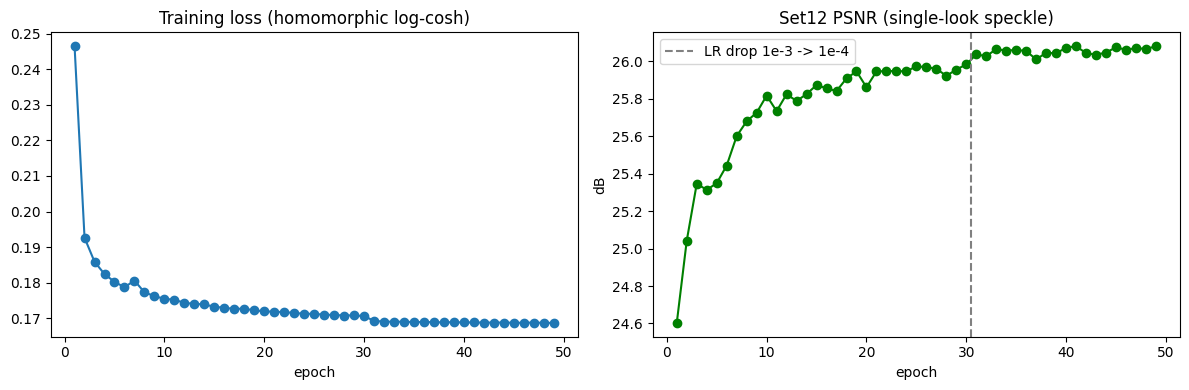

In [11]:
import matplotlib.pyplot as plt
ep = [h["epoch"] for h in history]
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(ep, [h["loss"] for h in history], marker="o")
ax[0].set_title("Training loss (homomorphic log-cosh)"); ax[0].set_xlabel("epoch")
ax[1].plot(ep, [h["val_psnr"] for h in history], marker="o", color="green")
ax[1].axvline(EPOCHS_STAGE1+0.5, ls="--", c="gray", label="LR drop 1e-3 -> 1e-4")
ax[1].set_title("Set12 PSNR (single-look speckle)"); ax[1].set_xlabel("epoch")
ax[1].set_ylabel("dB"); ax[1].legend()
plt.tight_layout(); plt.show()

In [12]:
# Stage 2: continue to the full EPOCHS
train_to(EPOCHS)
print("training complete. checkpoints in", SAVE_DIR)

epoch  50/50 | loss    0.1688 | Set12 PSNR 26.05 dB | lr 1e-04 | 399.4s
training complete. checkpoints in /content/drive/MyDrive/sarcnn_synthetic


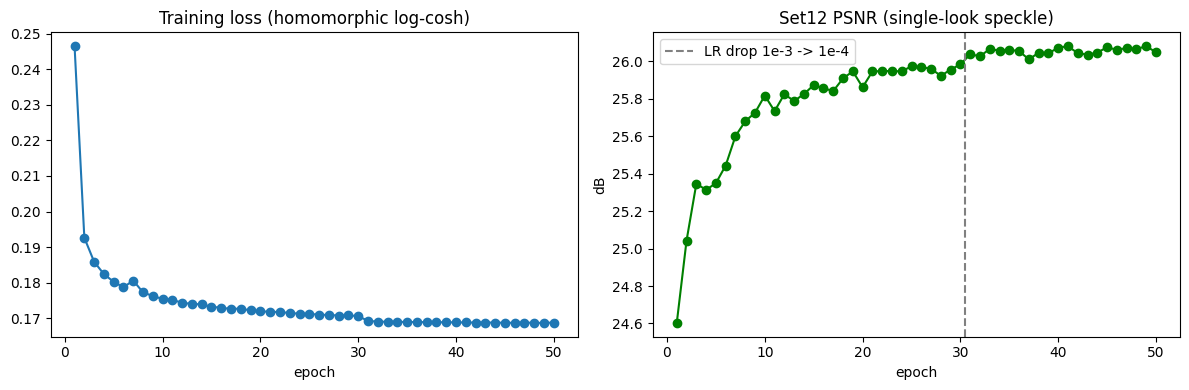

In [13]:
ep = [h["epoch"] for h in history]
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(ep, [h["loss"] for h in history], marker="o")
ax[0].set_title("Training loss (homomorphic log-cosh)"); ax[0].set_xlabel("epoch")
ax[1].plot(ep, [h["val_psnr"] for h in history], marker="o", color="green")
ax[1].axvline(EPOCHS_STAGE1+0.5, ls="--", c="gray", label="LR drop 1e-3 -> 1e-4")
ax[1].set_title("Set12 PSNR (single-look speckle)"); ax[1].set_xlabel("epoch")
ax[1].set_ylabel("dB"); ax[1].legend()
plt.tight_layout(); plt.show()